# Experimento Controlado - Baseline com Scaling

## Objetivo

Treinar 7 modelos em condições controladas:
- Mesmo dataset (train/test split com seed=42)
- Mesmo scaling (StandardScaler aplicado uniformemente)
- Mesmas métricas (AUC-ROC, PR-AUC, F1-Score, Accuracy, Precision, Recall)
- MLflow tracking de todos os runs

## Modelos
1. DummyClassifier (baseline)
2. LogisticRegression (simples)
3. LogisticRegression (balanced)
4. LogisticRegression (SMOTE)
5. RandomForestClassifier
6. XGBoostClassifier
7. MLPWrapper (PyTorch)

## Seção 1: Imports e Setup

In [10]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, precision_recall_curve, auc, confusion_matrix

from src.data.loader import TelcoDataLoader
from src.models.baseline import BaselineExperiment

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Imports concluidos")

Imports concluidos


## Seção 2: Carregar Dados

In [11]:
data_path = "../data/processed/telco_churn_processed.csv"

loader = TelcoDataLoader(data_path)
X_train, X_test, y_train, y_test = loader.pipeline_completo()

print(f"Dataset shape:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")
print(f"\nChurn rate (train): {y_train.mean():.2%}")
print(f"Churn rate (test): {y_test.mean():.2%}")


PIPELINE DE PREPARACAO DE DADOS

[OK] Dataset carregado: 7043 linhas x 33 colunas
[OK] Features selecionadas: 19
  - Distribuicao de Churn: {0: 5174, 1: 1869}
  - Taxa de Churn: 26.54%
[OK] Split treino/teste (80/20):
  - Treino: 5634 amostras
  - Teste: 1409 amostras
  - Taxa churn treino: 26.54%
  - Taxa churn teste: 26.54%
[OK] Variaveis categoricas codificadas: 16
[OK] Variaveis numericas normalizadas: 19
[OK] Variaveis categoricas codificadas: 16
[OK] Variaveis numericas normalizadas: 19

Dataset shape:
  X_train: (5634, 19)
  X_test: (1409, 19)
  y_train: (5634,)
  y_test: (1409,)

Churn rate (train): 26.54%
Churn rate (test): 26.54%


## Seção 3: Preparação de Dados

Dados já estão em train/test split com seed=42 e stratify=True

In [12]:
print(f"Dados preparados:")
print(f"  Features: {X_train.shape[1]}")
print(f"  Train samples: {X_train.shape[0]}")
print(f"  Test samples: {X_test.shape[0]}")
print(f"  Seed: 42")
print(f"  Stratified: True")

Dados preparados:
  Features: 19
  Train samples: 5634
  Test samples: 1409
  Seed: 42
  Stratified: True


## Seção 4: Experimento Controlado (COM SCALING)

Treina 7 modelos com StandardScaler aplicado uniformemente.
MLflow rastreia todos os runs.

In [13]:
import mlflow

# Encerrar qualquer run ativo anterior
if mlflow.active_run():
    mlflow.end_run()

exp = BaselineExperiment("Telco - Baseline com Scaling")

df_resultados, scaler = exp.treinar_esteira_controlada(
    X_train, X_test, y_train, y_test,
    aplicar_scaling=True,
    include_mlp=True,
    include_xgb_tuned=True
)

print("\nExperimento concluido!")
print(f"Total de modelos: {len(df_resultados)}")

c:\Users\Will\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026/04/21 16:57:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 16:57:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



INICIANDO ESTEIRA CONTROLADA DE MODELOS
Scaling: com StandardScaler

[1/7] Treinando DummyClassifier (most_frequent)...

[OK] DummyClassifier-most_frequent treinado
  - AUC-ROC: 0.5000
  - PR-AUC: 0.2654
  - Acurácia: 0.7346
  - Precision: 0.0000
  - Recall: 0.0000
  - F1-Score: 0.0000


c:\Users\Will\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026/04/21 16:57:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



[2/7] Treinando LogisticRegression (simples)...

[OK] LogisticRegression-simples treinado
  - AUC-ROC: 0.8479
  - PR-AUC: 0.6439
  - Acurácia: 0.8034
  - Precision: 0.6431
  - Recall: 0.5829
  - F1-Score: 0.6115
  - Top 5 features (coeficientes):
    Feature 17.0: 0.6916
    Feature 18.0: 0.4592
    Feature 15.0: 0.1882
    Feature 7.0: 0.1715
    Feature 2.0: 0.1514


2026/04/21 16:57:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\Will\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026/04/21 16:57:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...


[OK] XGBoostClassifier treinado
  - AUC-ROC: 0.8489
  - PR-AUC: 0.6650
  - Acurácia: 0.8055
  - Precision: 0.6603
  - Recall: 0.5508
  - F1-Score: 0.6006
  - Top 5 features (importância):
    Feature 14.0: 0.3893
    Feature 8.0: 0.0916
    Feature 3.0: 0.0911
    Feature 11.0: 0.0835
    Feature 7.0: 0.0717

[7/8] Treinando MLPWrapper (PyTorch)...


2026/04/21 16:58:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 16:58:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



[OK] MLPWrapper-PyTorch treinado
  - AUC-ROC: 0.8475
  - PR-AUC: 0.6469
  - Acurácia: 0.7367
  - Precision: 0.5024
  - Recall: 0.8289
  - F1-Score: 0.6256

[8/8] Treinando XGBoostClassifier (tuned)...


c:\Users\Will\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:58:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/04/21 16:58:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 16:58:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



[OK] XGBoostClassifier-tuned treinado
  - AUC-ROC: 0.8525
  - PR-AUC: 0.6660
  - Acurácia: 0.8041
  - Precision: 0.6561
  - Recall: 0.5508
  - F1-Score: 0.5988
  - Top 5 features (importância):
    Feature 14.0: 0.3513
    Feature 3.0: 0.1089
    Feature 8.0: 0.0977
    Feature 11.0: 0.0658
    Feature 7.0: 0.0623

COMPARAÇÃO DE BASELINES

                               test_auc_roc  test_pr_auc  test_accuracy  test_precision  test_recall  test_f1_score
XGBoostClassifier-tuned            0.852532     0.665997       0.804116        0.656051     0.550802       0.598837
XGBoostClassifier                  0.848924     0.665014       0.805536        0.660256     0.550802       0.600583
LogisticRegression-balanced        0.847966     0.643861       0.744500        0.512324     0.778075       0.617834
LogisticRegression-simples         0.847886     0.643898       0.803407        0.643068     0.582888       0.611501
MLPWrapper-PyTorch                 0.847464     0.646914       0.736693      

## Seção 5: Resultados


Ranking de Modelos (por AUC-ROC):
                               test_auc_roc  test_f1_score  test_accuracy  test_recall  test_precision
XGBoostClassifier-tuned            0.852532       0.598837       0.804116     0.550802        0.656051
XGBoostClassifier                  0.848924       0.600583       0.805536     0.550802        0.660256
LogisticRegression-balanced        0.847966       0.617834       0.744500     0.778075        0.512324
LogisticRegression-simples         0.847886       0.611501       0.803407     0.582888        0.643068
MLPWrapper-PyTorch                 0.847464       0.625631       0.736693     0.828877        0.502431
LogisticRegression-SMOTE           0.846369       0.617336       0.743080     0.780749        0.510490
RandomForestClassifier             0.836714       0.570162       0.793471     0.516043        0.636964
DummyClassifier-most_frequent      0.500000       0.000000       0.734564     0.000000        0.000000


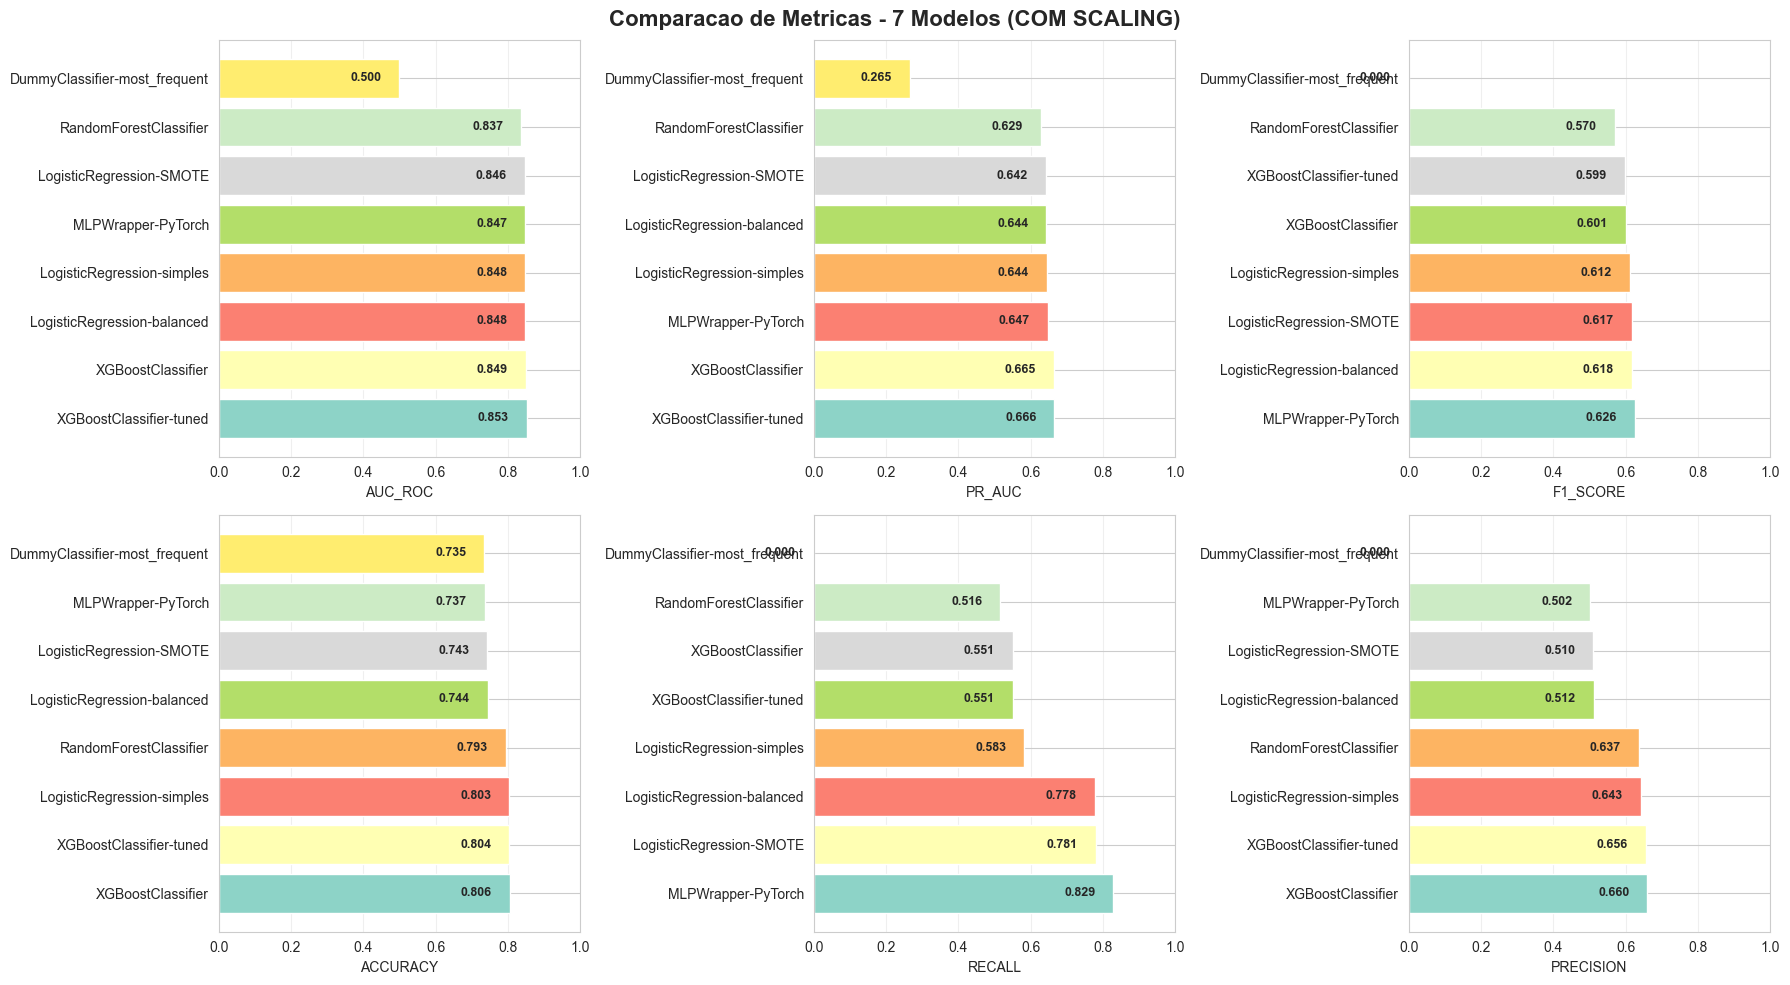

In [14]:
print("\nRanking de Modelos (por AUC-ROC):")
print(df_resultados[['test_auc_roc', 'test_f1_score', 'test_accuracy', 'test_recall', 'test_precision']].to_string())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_to_plot = ['test_auc_roc', 'test_pr_auc', 'test_f1_score', 'test_accuracy', 'test_recall', 'test_precision']
colors = plt.cm.Set3(np.linspace(0, 1, len(df_resultados)))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    values = df_resultados[metric].sort_values(ascending=False)
    bars = ax.barh(values.index, values.values, color=colors)
    ax.set_xlabel(metric.replace('test_', '').upper())
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)
    
    for bar in bars:
        width = bar.get_width()
        ax.text(width - 0.05, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='right', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparacao de Metricas - 7 Modelos (COM SCALING)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Sessão 6. Analisar Trade-offs: Falso Positivo vs. Falso Negativo

### Contexto de Negócio
- **FN (False Negative)**: Cliente em churn não identificado → Perda de receita (~$2000 LTV)
- **FP (False Positive)**: Cliente sem churn identificado como em churn → Custo de campanha ($50)
- **Razão de Custo**: FN é ~40x mais caro que FP

Analisaremos diferentes **thresholds** de decisão para encontrar o ponto ótimo entre minimizar FP e FN.


ANÁLISE DE TRADE-OFFS: TODOS OS MODELOS TREINADOS

📊 Carregando probabilidades dos modelos treinados...
  ✓ DummyClassifier-most_frequent
  ✓ LogisticRegression-simples
  ✓ LogisticRegression-balanced
  ✓ LogisticRegression-SMOTE
  ✓ RandomForestClassifier
  ✓ XGBoostClassifier
  ✓ MLPWrapper-PyTorch
  ✓ XGBoostClassifier-tuned

✅ 8/8 modelos carregados

📈 Analisando trade-offs para 8 modelos...
Analisando trade-offs para thresholds: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9  0.95]
Analisando trade-offs para thresholds: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9  0.95]
Analisando trade-offs para thresholds: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9  0.95]
Analisando trade-offs para thresholds: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9  0.95]
Analisando trade-offs para thresholds: [0.1  0.15 0.2  0.25 0.3  0.35 0.

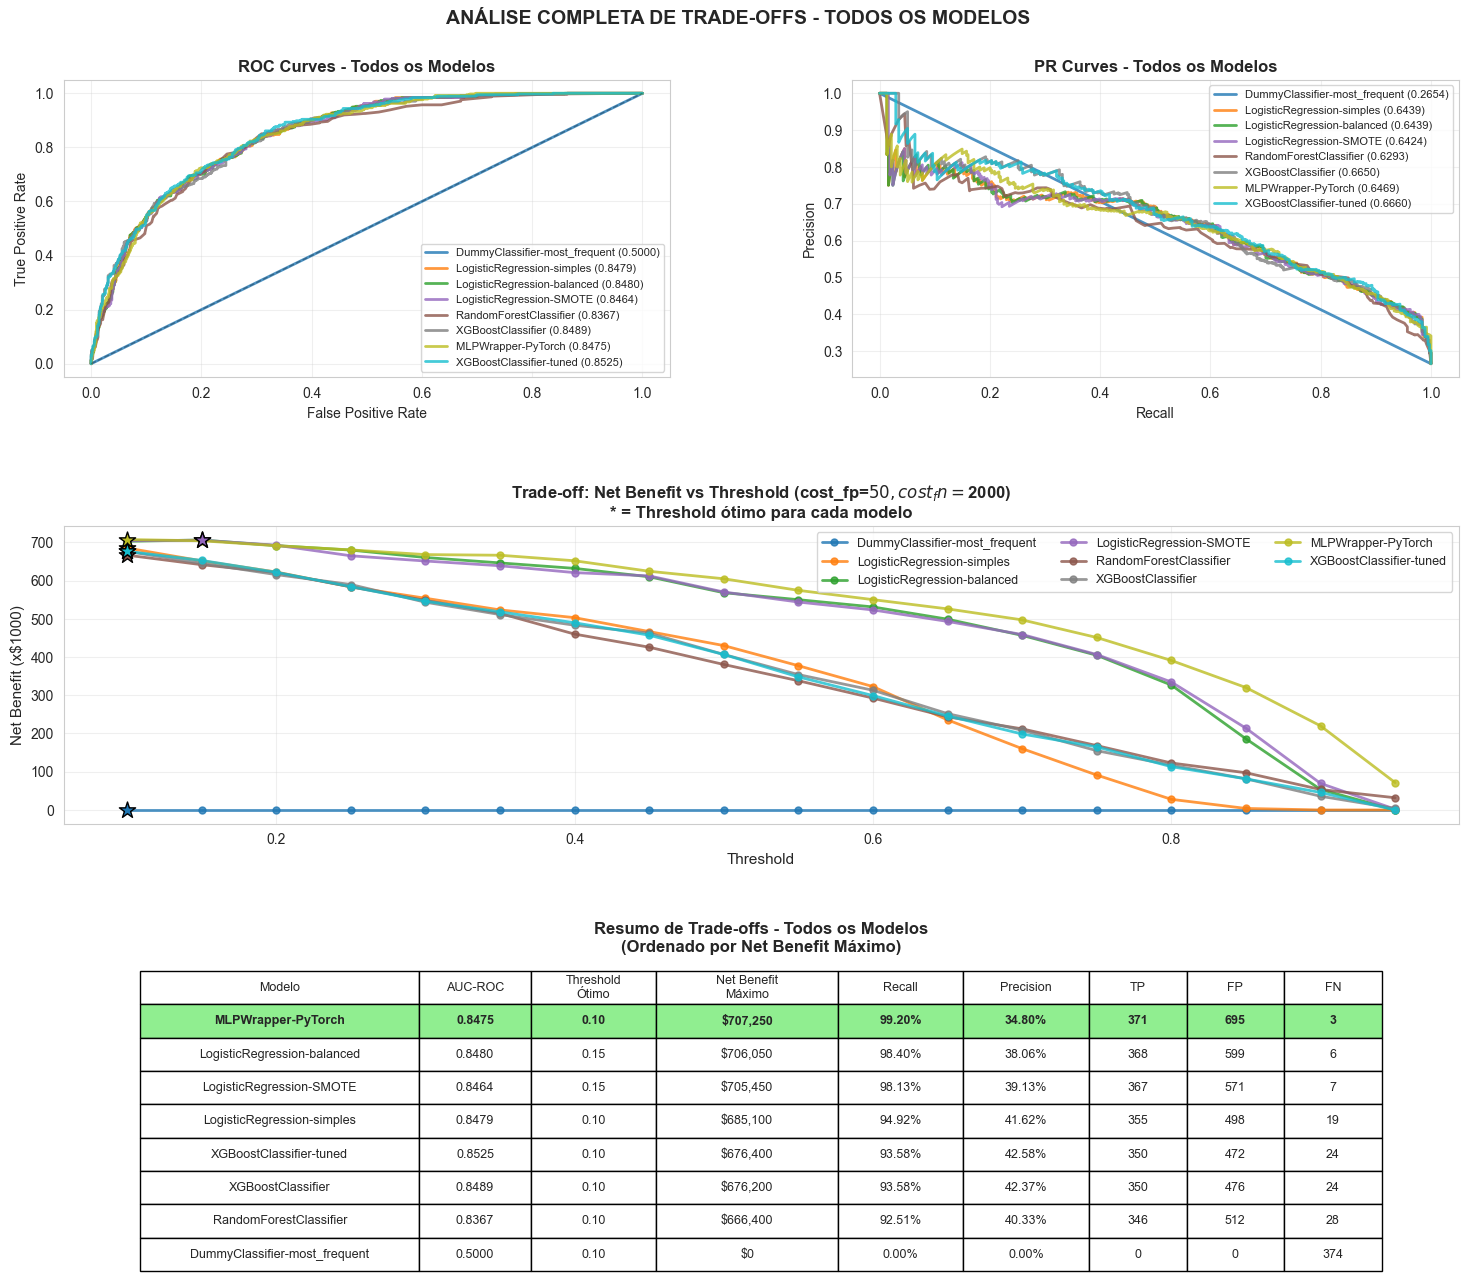


🏆 RECOMENDAÇÃO BASEADA EM TRADE-OFF:

✅ Modelo Recomendado: MLPWrapper-PyTorch
   Threshold Ótimo: 0.10
   Net Benefit Máximo: $707,250
   Recall no Threshold Ótimo: 0.9920
   Precision no Threshold Ótimo: 0.3480
   TP=371, FP=695, FN=3

📊 Resumo de Trade-off para TODOS os modelos (ordenado por Net Benefit):

Modelo                               Threshold     Net Benefit     Recall  Precision
-------------------------------------------------------------------------------------
MLPWrapper-PyTorch                        0.10 $      707,250    99.20%     34.80%
LogisticRegression-balanced               0.15 $      706,050    98.40%     38.06%
LogisticRegression-SMOTE                  0.15 $      705,450    98.13%     39.13%
LogisticRegression-simples                0.10 $      685,100    94.92%     41.62%
XGBoostClassifier-tuned                   0.10 $      676,400    93.58%     42.58%
XGBoostClassifier                         0.10 $      676,200    93.58%     42.37%
RandomForestClassif

In [ ]:
print("\n" + "="*70)
print("ANÁLISE DE TRADE-OFFS: TODOS OS MODELOS TREINADOS")
print("="*70)

# Função para análise de trade-offs com diferentes thresholds
def analyze_cost_tradeoff(y_true, y_proba, cost_fp=50, cost_fn=2000):
    """Analisar trade-off de custos para diferentes thresholds"""
    thresholds = np.arange(0.10, 1.0, 0.05)    
    results = []
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        fp_cost = fp * cost_fp
        fn_cost = fn * cost_fn
        net_benefit = (tp * cost_fn) - fp_cost  # Benefit from TPs minus cost of FPs
        
        results.append({
            'threshold': threshold,
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            'precision': precision,
            'recall': recall,
            'fp_cost': fp_cost,
            'fn_cost': fn_cost,
            'net_benefit': net_benefit
        })
    
    return pd.DataFrame(results)

# Carregar probabilidades dos modelos treinados
print("\n📊 Carregando probabilidades dos modelos treinados...")

# Converter X_test para array numpy se for DataFrame
X_test_array = X_test.values if isinstance(X_test, pd.DataFrame) else np.asarray(X_test)

probas_dict = {}
for model_name, modelo in exp._modelos.items():
    try:
        # Todos os modelos recebem array numpy explicitamente
        y_proba = modelo.predict_proba(X_test_array)
        
        # Converter DataFrame para array se necessário
        if isinstance(y_proba, pd.DataFrame):
            y_proba = y_proba.values
        elif not isinstance(y_proba, np.ndarray):
            y_proba = np.array(y_proba)
        
        # Garantir que temos as probabilidades da classe 1
        if y_proba.ndim > 1:
            y_proba = y_proba[:, 1]  # Pega segunda coluna (classe positiva)
        
        y_proba = np.asarray(y_proba).flatten()  # Garante 1D array
        probas_dict[model_name] = y_proba
        print(f"  ✓ {model_name}")
    except Exception as e:
        print(f"  ✗ {model_name}: {type(e).__name__}: {str(e)}")

print(f"\n✅ {len(probas_dict)}/{len(exp._modelos)} modelos carregados")

# Analisar trade-offs para TODOS os modelos
print(f"\n📈 Analisando trade-offs para {len(probas_dict)} modelos...")

all_models = list(probas_dict.keys())
best_thresholds = {}

# Calcular trade-offs para todos os modelos
for model_name in all_models:
    tradeoff_df = analyze_cost_tradeoff(y_test.values, probas_dict[model_name])
    best_idx = tradeoff_df['net_benefit'].idxmax()
    best_thresholds[model_name] = tradeoff_df.iloc[best_idx]

# Visualizações
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.5, wspace=0.3, top=0.93, bottom=0.08)

# 1. ROC Curves - Todos os modelos
ax1 = fig.add_subplot(gs[0, 0])
colors = plt.cm.tab10(np.linspace(0, 1, len(all_models)))
for idx, model_name in enumerate(all_models):
    y_proba = probas_dict[model_name]
    fpr, tpr, _ = roc_curve(y_test.values, y_proba)
    auc_score = df_resultados.loc[model_name, 'test_auc_roc']
    ax1.plot(fpr, tpr, label=f"{model_name} ({auc_score:.4f})", 
            color=colors[idx], linewidth=2, alpha=0.8)

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
ax1.set_xlabel('False Positive Rate', fontsize=10)
ax1.set_ylabel('True Positive Rate', fontsize=10)
ax1.set_title('ROC Curves - Todos os Modelos', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(alpha=0.3)

# 2. PR Curves - Todos os modelos
ax2 = fig.add_subplot(gs[0, 1])
for idx, model_name in enumerate(all_models):
    y_proba = probas_dict[model_name]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test.values, y_proba)
    pr_auc = df_resultados.loc[model_name, 'test_pr_auc']
    ax2.plot(recall_vals, precision_vals, label=f"{model_name} ({pr_auc:.4f})", 
            color=colors[idx], linewidth=2, alpha=0.8)

ax2.set_xlabel('Recall', fontsize=10)
ax2.set_ylabel('Precision', fontsize=10)
ax2.set_title('PR Curves - Todos os Modelos', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(alpha=0.3)

# 3. Net Benefit vs Threshold - Todos os modelos em um gráfico
ax3 = fig.add_subplot(gs[1, :])
for idx, model_name in enumerate(all_models):
    tradeoff_df = analyze_cost_tradeoff(y_test.values, probas_dict[model_name])
    ax3.plot(tradeoff_df['threshold'], tradeoff_df['net_benefit']/1000, 
            marker='o', label=model_name, color=colors[idx], linewidth=2, markersize=5, alpha=0.8)
    
    # Marcar ponto ótimo
    best_info = best_thresholds[model_name]
    ax3.scatter(best_info['threshold'], best_info['net_benefit']/1000,
              s=150, color=colors[idx], marker='*', edgecolor='black', linewidth=1, zorder=5)

ax3.set_xlabel('Threshold', fontsize=11)
ax3.set_ylabel('Net Benefit (x$1000)', fontsize=11)
ax3.set_title('Trade-off: Net Benefit vs Threshold (cost_fp=$50, cost_fn=$2000)\n* = Threshold ótimo para cada modelo', 
             fontsize=12, fontweight='bold')
ax3.legend(fontsize=9, ncol=3, loc='best')
ax3.grid(alpha=0.3)

# 4. Tabela comparativa - Trade-offs de todos os modelos
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('tight')
ax4.axis('off')

# Ordenar modelos por net_benefit decrescente
models_sorted = sorted(all_models, key=lambda m: best_thresholds[m]['net_benefit'], reverse=True)

table_data = []
for model_name in models_sorted:
    best_info = best_thresholds[model_name]
    auc_score = df_resultados.loc[model_name, 'test_auc_roc']
    table_data.append([
        model_name,
        f"{auc_score:.4f}",
        f"{best_info['threshold']:.2f}",
        f"${best_info['net_benefit']:,.0f}",
        f"{best_info['recall']:.2%}",
        f"{best_info['precision']:.2%}",
        f"{best_info['TP']:.0f}",
        f"{best_info['FP']:.0f}",
        f"{best_info['FN']:.0f}"
    ])

table = ax4.table(
    cellText=table_data,
    colLabels=['Modelo', 'AUC-ROC', 'Threshold\nÓtimo', 'Net Benefit\nMáximo', 'Recall', 'Precision', 'TP', 'FP', 'FN'],
    cellLoc='center',
    loc='center',
    colWidths=[0.2, 0.08, 0.09, 0.13, 0.09, 0.09, 0.07, 0.07, 0.07]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Colorir primeira linha (melhor modelo)
for i in range(9):
    table[(1, i)].set_facecolor('#90EE90')  # Verde claro
    table[(1, i)].set_text_props(weight='bold')

ax4.set_title('Resumo de Trade-offs - Todos os Modelos\n(Ordenado por Net Benefit Máximo)', 
             pad=15, fontsize=12, fontweight='bold')

plt.suptitle('ANÁLISE COMPLETA DE TRADE-OFFS - TODOS OS MODELOS', 
            fontsize=14, fontweight='bold', y=0.98)

plt.show()

# Encontrar melhor modelo + threshold
best_model_final = models_sorted[0]
best_threshold_final = best_thresholds[best_model_final]

print(f"\n" + "="*70)
print("🏆 RECOMENDAÇÃO BASEADA EM TRADE-OFF:")
print("="*70)
print(f"\n✅ Modelo Recomendado: {best_model_final}")
print(f"   Threshold Ótimo: {best_threshold_final['threshold']:.2f}")
print(f"   Net Benefit Máximo: ${best_threshold_final['net_benefit']:,.0f}")
print(f"   Recall no Threshold Ótimo: {best_threshold_final['recall']:.4f}")
print(f"   Precision no Threshold Ótimo: {best_threshold_final['precision']:.4f}")
print(f"   TP={best_threshold_final['TP']:.0f}, FP={best_threshold_final['FP']:.0f}, FN={best_threshold_final['FN']:.0f}")

# Mostrar detalhe para todos os modelos
print(f"\n📊 Resumo de Trade-off para TODOS os modelos (ordenado por Net Benefit):")
print(f"\n{'Modelo':<35} {'Threshold':>10} {'Net Benefit':>15} {'Recall':>10} {'Precision':>10}")
print("-" * 85)
for model_name in models_sorted:
    best_info = best_thresholds[model_name]
    print(f"{model_name:<35} {best_info['threshold']:>10.2f} ${best_info['net_benefit']:>13,.0f} {best_info['recall']:>9.2%} {best_info['precision']:>10.2%}")

# Guardar para a próxima célula
recommended_model_name = best_model_final
recommended_threshold = best_threshold_final['threshold']
recommended_net_benefit = best_threshold_final['net_benefit']

print(f"\n📌 Variáveis salvas para próxima etapa:")
print(f"   recommended_model_name = '{recommended_model_name}'")
print(f"   recommended_threshold = {recommended_threshold:.2f}")
print(f"   recommended_net_benefit = ${recommended_net_benefit:,.0f}")
print(f"\n   Modelo recomendado será salvo na próxima etapa com threshold={recommended_threshold:.2f}")
print("\n" + "="*70)

## Seção 7: Salvar Melhor Modelo (Com Trade-off Otimizado)

Agora que determinamos o melhor modelo e seu threshold ótimo através da análise de trade-offs, vamos salvá-lo com toda a metadata necessária para uso em produção.

In [17]:
print("\n" + "="*70)
print("SALVANDO MELHOR MODELO (BASEADO NA ANÁLISE DE TRADE-OFF)")
print("="*70)

# Usar o modelo recomendado da análise de trade-offs
print(f"\n🎯 Modelo Recomendado: {recommended_model_name}")
print(f"   Threshold Ótimo: {recommended_threshold:.2f}")
print(f"   Net Benefit Esperado: ${recommended_net_benefit:,.0f}")

# Recuperar o modelo treinado
best_model_obj = exp._modelos[recommended_model_name]
best_metrics = df_resultados.loc[recommended_model_name]

print(f"\n📊 Métricas do Modelo (threshold padrão 0.5):")
print(f"  AUC-ROC: {best_metrics['test_auc_roc']:.4f}")
print(f"  PR-AUC: {best_metrics['test_pr_auc']:.4f}")
print(f"  F1-Score: {best_metrics['test_f1_score']:.4f}")
print(f"  Accuracy: {best_metrics['test_accuracy']:.4f}")
print(f"  Recall: {best_metrics['test_recall']:.4f}")
print(f"  Precision: {best_metrics['test_precision']:.4f}")

# Criar metadata com informações do trade-off
best_model_data = {
    'model_name': recommended_model_name,
    'model_object': best_model_obj,
    'scaler': scaler,
    'metrics': best_metrics.to_dict(),
    'preprocessing': 'StandardScaler',
    'seed': 42,
    'n_features': X_train.shape[1],
    'train_size': X_train.shape[0],
    'test_size': X_test.shape[0],
    # Informações de trade-off
    'recommended_threshold': recommended_threshold,
    'net_benefit_at_threshold': recommended_net_benefit,
    'trade_off_metrics': {
        'recall': best_threshold_final['recall'],
        'precision': best_threshold_final['precision'],
        'fp_cost': best_threshold_final['fp_cost'],
        'fn_cost': best_threshold_final['fn_cost']
    }
}

output_path = '../models/best_model_with_metadata.pkl'
os.makedirs('../models', exist_ok=True)
pickle.dump(best_model_data, open(output_path, 'wb'))

print(f"\n✅ Arquivo salvo: {output_path}")
print(f"\n📦 Metadata incluído:")
print(f"   - model_name: {best_model_data['model_name']}")
print(f"   - recommended_threshold: {best_model_data['recommended_threshold']:.2f}")
print(f"   - net_benefit_at_threshold: ${best_model_data['net_benefit_at_threshold']:,.0f}")
print(f"   - trade_off_metrics: {best_model_data['trade_off_metrics']}")
print(f"   - preprocessing: {best_model_data['preprocessing']}")
print(f"   - seed: {best_model_data['seed']}")
print(f"\n" + "="*70)


SALVANDO MELHOR MODELO (BASEADO NA ANÁLISE DE TRADE-OFF)

🎯 Modelo Recomendado: MLPWrapper-PyTorch
   Threshold Ótimo: 0.10
   Net Benefit Esperado: $707,250

📊 Métricas do Modelo (threshold padrão 0.5):
  AUC-ROC: 0.8475
  PR-AUC: 0.6469
  F1-Score: 0.6256
  Accuracy: 0.7367
  Recall: 0.8289
  Precision: 0.5024

✅ Arquivo salvo: ../models/best_model_with_metadata.pkl

📦 Metadata incluído:
   - model_name: MLPWrapper-PyTorch
   - recommended_threshold: 0.10
   - net_benefit_at_threshold: $707,250
   - trade_off_metrics: {'recall': np.float64(0.9919786096256684), 'precision': np.float64(0.34803001876172607), 'fp_cost': np.float64(34750.0), 'fn_cost': np.float64(6000.0)}
   - preprocessing: StandardScaler
   - seed: 42

